# Wine Quality — Data Cleaning & Feature Engineering

Pipeline:
1. Binarize `quality` (>=7 -> 1, else 0) into `good_quality`
2. Drop the original `quality` column
3. Engineer `total_acidity`, `acidity_ratio`, `free_to_total_sulfur`, `alcohol_level` (binned)
4. One-hot encode `alcohol_level`
5. Save to `data/winequality-red_cleaned.csv`

## 1. Imports & Load Raw Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append(".")
from utils import (load_data, binarize_quality, drop_quality,
                   create_features, preprocess_data)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

%matplotlib inline

In [2]:
df = load_data("data/winequality-red.csv")
print(f"Raw shape: {df.shape}")
df.head()

Raw shape: (1599, 12)


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## 2. Missing / Invalid Values

In [3]:
missing = df.isnull().sum()
print(f"Total missing values: {missing.sum()}")
print(f"Duplicate rows      : {df.duplicated().sum()}")

Total missing values: 0
Duplicate rows      : 240


## 3. Binarize Quality

In [4]:
df_bin = binarize_quality(df, threshold=7)
print("Class distribution:")
print(df_bin["good_quality"].value_counts())
print(f"Good-wine ratio: {df_bin['good_quality'].mean():.3f}")

Class distribution:
good_quality
0    1382
1     217
Name: count, dtype: int64
Good-wine ratio: 0.136


## 4. Distribution Comparison Before/After

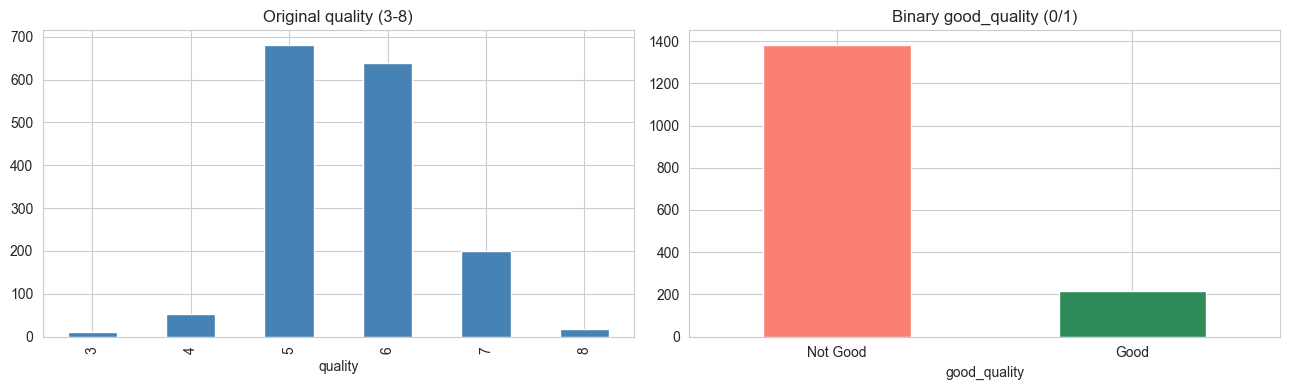

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df["quality"].value_counts().sort_index().plot(kind="bar", color="steelblue", ax=axes[0])
axes[0].set_title("Original quality (3-8)")
df_bin["good_quality"].value_counts().plot(kind="bar", color=["salmon","seagreen"], ax=axes[1])
axes[1].set_title("Binary good_quality (0/1)")
axes[1].set_xticklabels(["Not Good","Good"], rotation=0)
plt.tight_layout(); plt.show()

## 5. Drop Original Quality, Engineer Features

In [6]:
df_no_q = drop_quality(df_bin)
df_feat = create_features(df_no_q)
new_cols = [c for c in df_feat.columns if c not in df_no_q.columns]
print(f"New features: {new_cols}")
df_feat.head()

New features: ['total_acidity', 'acidity_ratio', 'free_to_total_sulfur', 'alcohol_level']


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,good_quality,total_acidity,acidity_ratio,free_to_total_sulfur,alcohol_level
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0,8.10,10.571429,0.323529,low
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0,8.68,8.863636,0.373134,medium
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0,8.56,10.263158,0.277778,medium
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,0,11.48,40.000000,0.283333,medium
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0,8.10,10.571429,0.323529,low


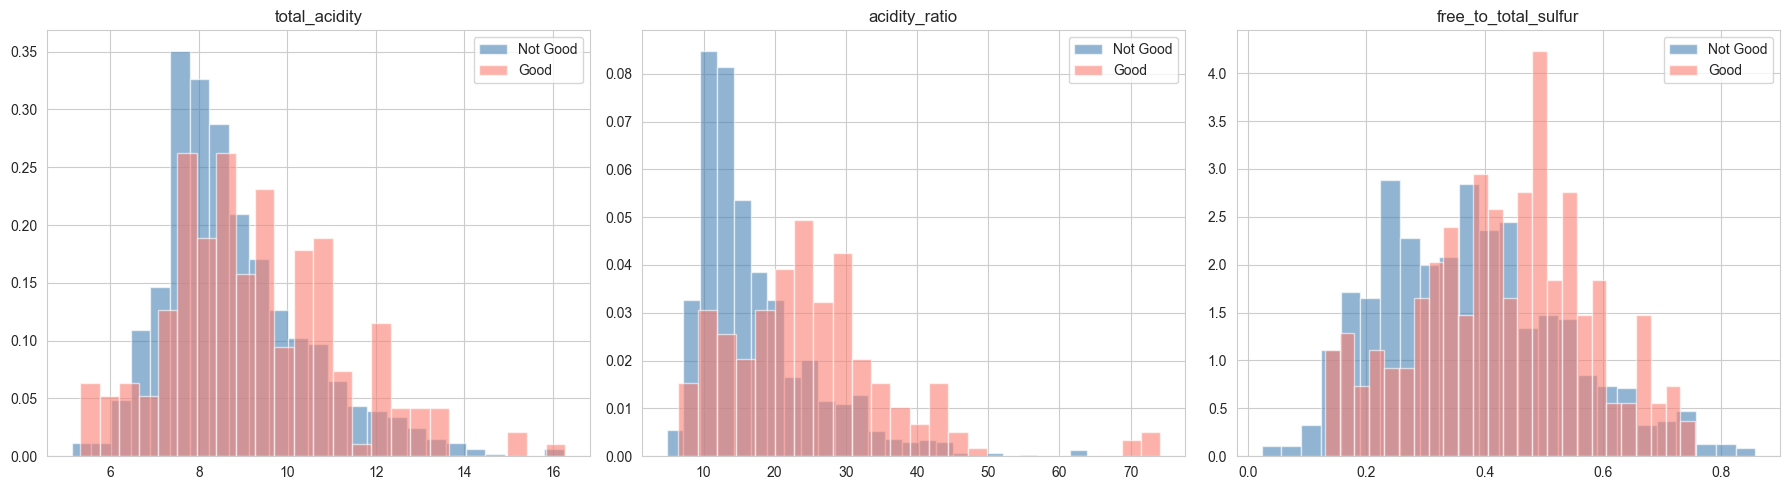

In [7]:
# Visualize ratios by good_quality
ratios = ["total_acidity", "acidity_ratio", "free_to_total_sulfur"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(ratios):
    for q, color, label in [(0, "steelblue", "Not Good"), (1, "salmon", "Good")]:
        s = df_feat[df_feat["good_quality"] == q][col]
        axes[i].hist(s, bins=25, alpha=0.6, color=color, label=label, density=True)
    axes[i].set_title(col); axes[i].legend()
plt.tight_layout(); plt.show()

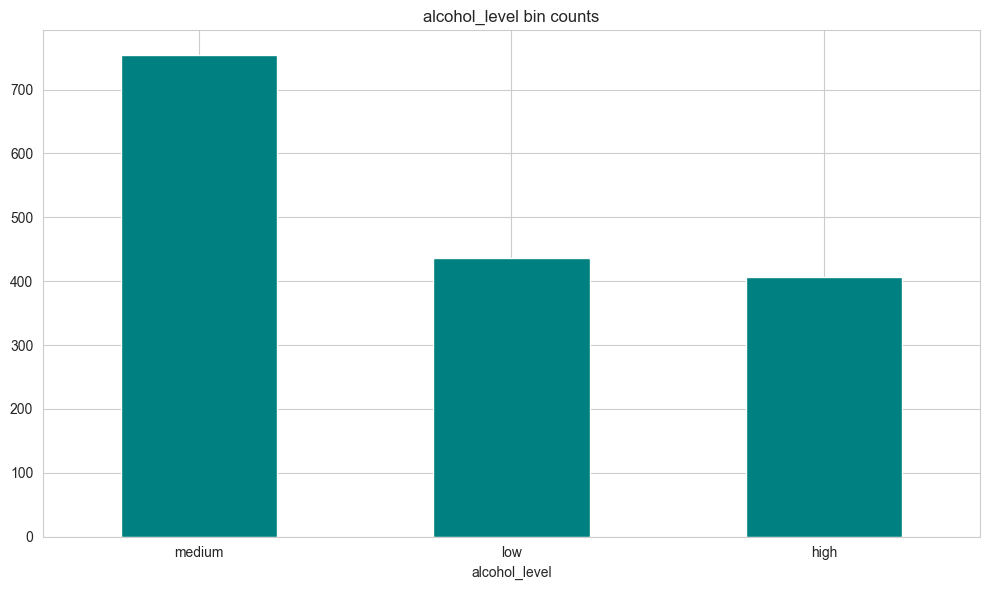

alcohol_level
low       0.009
medium    0.095
high      0.346
Name: good_quality, dtype: float64


In [8]:
# Alcohol bin shares
df_feat["alcohol_level"].value_counts().plot(kind="bar", color="teal")
plt.title("alcohol_level bin counts")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()
print(df_feat.groupby("alcohol_level", observed=True)["good_quality"].mean().round(3))

## 6. One-Hot Encoding & Pipeline

In [9]:
df_processed = preprocess_data(df, threshold=7)
print(f"Processed shape: {df_processed.shape}")
print(f"Missing values : {df_processed.isnull().sum().sum()}")
df_processed.head()

Processed shape: (1599, 17)
Missing values : 0


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,good_quality,total_acidity,acidity_ratio,free_to_total_sulfur,alcohol_level_medium,alcohol_level_high
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0,8.10,10.571429,0.323529,False,False
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0,8.68,8.863636,0.373134,True,False
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0,8.56,10.263158,0.277778,True,False
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,0,11.48,40.000000,0.283333,True,False
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0,8.10,10.571429,0.323529,False,False


## 7. Sanity Checks & Save

In [10]:
assert df_processed["good_quality"].isin([0, 1]).all()
assert df_processed.isnull().sum().sum() == 0
assert "quality" not in df_processed.columns
print("All checks passed.")

All checks passed.


In [11]:
df_processed.to_csv("data/winequality-red_cleaned.csv", index=False)
print(f"Saved data/winequality-red_cleaned.csv ({df_processed.shape[0]} rows, {df_processed.shape[1]} cols)")

Saved data/winequality-red_cleaned.csv (1599 rows, 17 cols)
